In [19]:
#Libraries import 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import(
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    confusion_matrix, 
    classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn import linear_model
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.naive_bayes import GaussianNB 
from sklearn.svm import SVC
from sklearn import linear_model as logistic_model
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Data import
try:
    data = pd.read_csv("F:\Final Assignment\data.csv")
    print("Data imported successfully!")
except FileNotFoundError:
    print("File not found!")

Data imported successfully!


In [14]:
#Display basic information about the dataset
print(f"Dataset shape: {data.shape[0]} rows and {data.shape[1]} columns")
print(f"columns name and data types:\n{data.dtypes}")
data.head()

Dataset shape: 569 rows and 32 columns
columns name and data types:
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst      

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
#Duplicate records check
duplicates = data.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    data.drop_duplicates(inplace=True)
    print(f"{duplicates} duplicate rows removed.")
else:
    print("\nNo duplicate rows found.")

#missing value analysis
print("\nMissing Value:\n", data.isnull().sum())


Duplicate rows found: 0

No duplicate rows found.

Missing Value:
 id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype

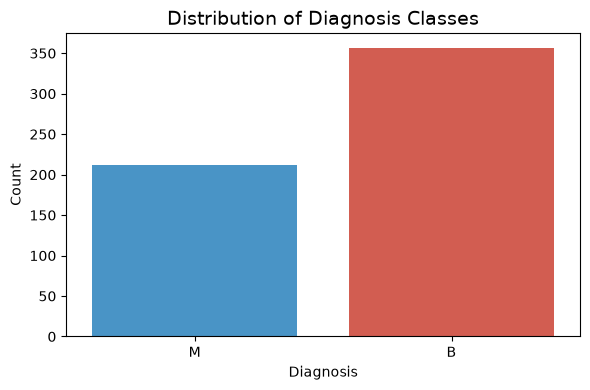

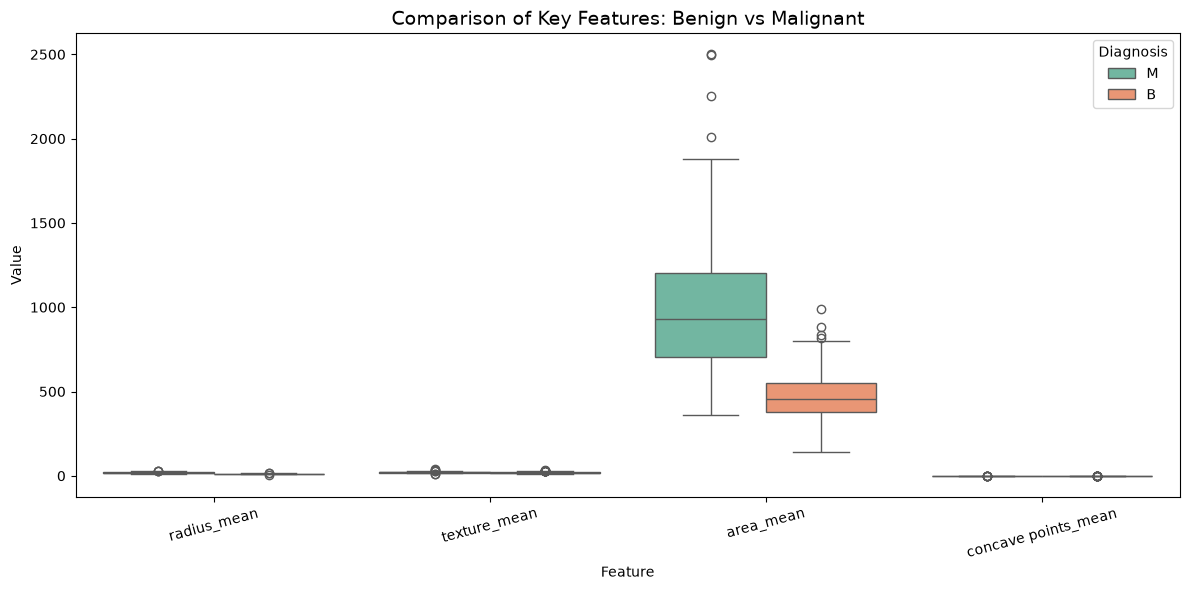

In [20]:
#EDA and Visualization
# Plot 1: Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=data, palette=['#3498db', '#e74c3c'])
plt.title("Distribution of Diagnosis Classes", fontsize=14)
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=300) 
plt.show()

#2 Plot 2: Box plots for key features by diagonals
key_features = ['radius_mean', 'texture_mean', 'area_mean', 'concave points_mean']

# Melt the dataframe so seaborn can plot multiple features easily
data_melted = data.melt(
    id_vars="diagnosis", 
    value_vars=key_features, 
    var_name="Feature", 
    value_name="Value"
)

plt.figure(figsize=(12, 6))
sns.boxplot(x="Feature", y="Value", hue="diagnosis", data=data_melted, palette="Set2")
plt.title("Comparison of Key Features: Benign vs Malignant", fontsize=14)
plt.xticks(rotation=15)
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.savefig("feature_boxplots.png", dpi=300)
plt.show()


In [21]:
#feature Engineering
y = data.diagnosis
list = ['id', 'diagnosis']
x = data.drop(list, axis=1)
x.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [22]:
#Train Test SPlit
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, stratify=y, random_state = 42)
print(f"Training set shape: {x_train.shape[0]} rows and {x_train.shape[1]} columns")
print(f"Test set shape: {x_test.shape[0]} rows and {x_test.shape[1]} columns")

Training set shape: 455 rows and 30 columns
Test set shape: 114 rows and 30 columns


In [23]:
#preprocessing and training pipeline

voting = VotingClassifier(estimators=[
        ('nb', GaussianNB()),
        ('lr', linear_model.LogisticRegression(max_iter=1000, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)),
        ('svm', SVC(kernel='linear', random_state=42, probability=True))
    ],
    voting ='soft')

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', voting)
])

pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_test)


In [24]:
#Evaluate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}   
cv_results = []

for name, model in pipe.named_steps['classifier'].estimators:
    model.fit(x_train, y_train)
    y_pred_model = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred_model)
    precision = precision_score(y_test, y_pred_model, pos_label='M')
    recall = recall_score(y_test, y_pred_model, pos_label='M')
    f1 = f1_score(y_test, y_pred_model, pos_label='M')
    roc_auc = roc_auc_score(y_test.map({'B': 0, 'M': 1}), model.predict_proba(x_test)[:, 1])
    
    cv_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })

print("Evaluation results:\n")

print("confusion_matrix:\n", confusion_matrix(y_test, y_pred))
print("\n")
print("classification_report:\n", classification_report(y_test, y_pred))

results_df = pd.DataFrame(cv_results)
results_df = results_df.sort_values(by='ROC AUC', ascending=False)
print(results_df)

Evaluation results:

confusion_matrix:
 [[72  0]
 [ 5 37]]


classification_report:
               precision    recall  f1-score   support

           B       0.94      1.00      0.97        72
           M       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

  Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0    nb  0.938596   1.000000  0.833333  0.909091  0.993386
1    lr  0.938596   0.972973  0.857143  0.911392  0.992725
3   svm  0.921053   0.945946  0.833333  0.886076  0.991733
2   knn  0.912281   0.970588  0.785714  0.868421  0.954696


In [ ]:
#Hyperparameter tuning for SVC using GridSearchCV

param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.1],
    "svm__kernel": ["rbf", "linear"],
    "nb__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "knn__n_neighbors": [3, 5, 7, 9]
}

search = GridSearchCV(
    estimator=voting,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    error_score="raise",
    verbose=2
)

search.fit(x_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV accuracy:", search.best_score_)
print("Test accuracy:", search.score(x_test, y_test))